In [14]:
# =============================================================================
# 0. Imports et rechargement des données
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import re

# Recharger les données 
df = pd.read_pickle("../data/df_complet.pkl")


In [15]:
print(f"DataFrame chargé : {len(df)} lignes, {len(df.columns)} colonnes")

DataFrame chargé : 12746 lignes, 47 colonnes


In [16]:
# =============================================================================
# 1. Statistiques descriptives du corpus
# =============================================================================
print("\n=== Répartition par année ===")
print(df['year'].value_counts().sort_index())

print("\n=== Répartition par type d'élection ===")
print(df['election_type'].value_counts())

print("\n=== Top 15 des partis (titulaire-soutien) ===")
print(df['titulaire-soutien'].value_counts().head(15))

print("\n=== Répartition par sexe ===")
print(df['titulaire-sexe'].value_counts())

print("\n=== Répartition par tranche d'âge ===")
print(df['titulaire-age-tranche'].value_counts())


# =============================================================================
# Nettoyage du texte
# =============================================================================
import string

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Minuscules
    text = text.lower()
    # Supprimer les retours à la ligne
    text = text.replace('\n', ' ').replace('\r', ' ')
    # Supprimer la ponctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Supprimer les chiffres
    text = re.sub(r'\d+', '', text)
    # Supprimer les espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)

# Vérification
print("=== Exemple de texte original ===")
print(df['text'].iloc[0][:300])
print("\n=== Exemple de texte nettoyé ===")
print(df['text_clean'].iloc[0][:300])

# =============================================================================
# Stopwords et tokenisation
# =============================================================================
# Stopwords français de base + mots très fréquents dans les professions de foi
STOPWORDS_FR = {
    'le', 'la', 'les', 'de', 'des', 'du', 'un', 'une', 'et', 'en', 'à',
    'au', 'aux', 'ce', 'ces', 'que', 'qui', 'dans', 'pour', 'par', 'sur',
    'avec', 'son', 'ses', 'sa', 'se', 'ne', 'pas', 'nous', 'vous', 'ils',
    'est', 'sont', 'ont', 'été', 'être', 'avoir', 'fait', 'faire', 'plus',
    'tout', 'tous', 'toute', 'toutes', 'mais', 'ou', 'où', 'si', 'leur',
    'leurs', 'elle', 'elles', 'il', 'je', 'me', 'mon', 'ma', 'mes',
    'notre', 'nos', 'votre', 'vos', 'même', 'aussi', 'bien', 'peut',
    'cette', 'cet', 'dont', 'comme', 'sans', 'entre', 'très', 'après',
    'avant', 'autres', 'autre', 'encore', 'quand', 'car', 'donc',
    'sera', 'été', 'été', 'non', 'oui', 'puis', 'ici', 'là',
    'ya', 'ça', 'cela', 'ceci', 'on', 'ny', 'na', 'ni',
    # Mots très courants dans les professions de foi
    'circonscription', 'candidat', 'candidate', 'élections', 'législatives',
    'république', 'française', 'france', 'département', 'juin', 'mars',
    'tour', 'scrutin', 'vote', 'voter', 'électeurs', 'électeur'
}

def tokenize(text):
    """Tokenise et supprime les stopwords"""
    tokens = text.split()
    return [t for t in tokens if t not in STOPWORDS_FR and len(t) > 2]

df['tokens'] = df['text_clean'].apply(tokenize)
df['n_tokens'] = df['tokens'].apply(len)

print(f"\nNombre moyen de tokens par document : {df['n_tokens'].mean():.0f}")
print(f"Exemple de tokens : {df['tokens'].iloc[0][:20]}")

# =============================================================================
# Mots les plus fréquents
# =============================================================================
def get_top_words(df_subset, n=20):
    all_tokens = [token for tokens in df_subset['tokens'] for token in tokens]
    return Counter(all_tokens).most_common(n)

# Top mots global
print("\n=== Top 20 mots globaux ===")
for word, count in get_top_words(df):
    print(f"  {word}: {count}")

# =============================================================================
#  Regroupement des partis politiques
# =============================================================================
# Les partis ont beaucoup de variantes, on les regroupe en grandes familles
def classify_party(soutien):
    if not isinstance(soutien, str):
        return 'Autre'
    soutien = soutien.lower()
    if any(x in soutien for x in ['communiste', 'pcf']):
        return 'PCF'
    if any(x in soutien for x in ['socialiste', 'ps ', 'parti socialiste']):
        return 'PS'
    if any(x in soutien for x in ['rassemblement pour la république', 'rpr', 'gaulliste']):
        return 'RPR'
    if any(x in soutien for x in ['union pour la démocratie française', 'udf']):
        return 'UDF'
    if any(x in soutien for x in ['front national', 'fn']):
        return 'FN'
    if any(x in soutien for x in ['écologi', 'vert']):
        return 'Ecologistes'
    if any(x in soutien for x in ['radical']):
        return 'Radicaux'
    if 'non mentionné' in soutien:
        return 'Non mentionné'
    return 'Autre'

df['parti_famille'] = df['titulaire-soutien'].apply(classify_party)

print("\n=== Répartition par famille politique ===")
print(df['parti_famille'].value_counts())


# =============================================================================
# Sauvegarde du DataFrame enrichi
# =============================================================================
df.to_pickle("../data/df_explore.pkl")
print(f"\nDataFrame enrichi sauvegardé : {len(df)} lignes, {len(df.columns)} colonnes")
print(f"Nouvelles colonnes : text_clean, tokens, n_tokens, parti_famille")



=== Répartition par année ===
year
1981    3182
1988    3628
1993    5936
Name: count, dtype: int64

=== Répartition par type d'élection ===
election_type
legislatives    12746
Name: count, dtype: int64

=== Top 15 des partis (titulaire-soutien) ===
titulaire-soutien
non mentionné                                                          3035
Parti communiste français                                              1532
Front national                                                         1233
Parti socialiste                                                        989
Rassemblement pour la République;Union pour la démocratie française     759
Union pour la démocratie française;Rassemblement pour la République     454
Lutte ouvrière                                                          393
Nouveaux écologistes du rassemblement nature et animaux                 387
Verts;Génération écologie                                               293
Rassemblement pour la République               

Style configuré ✓


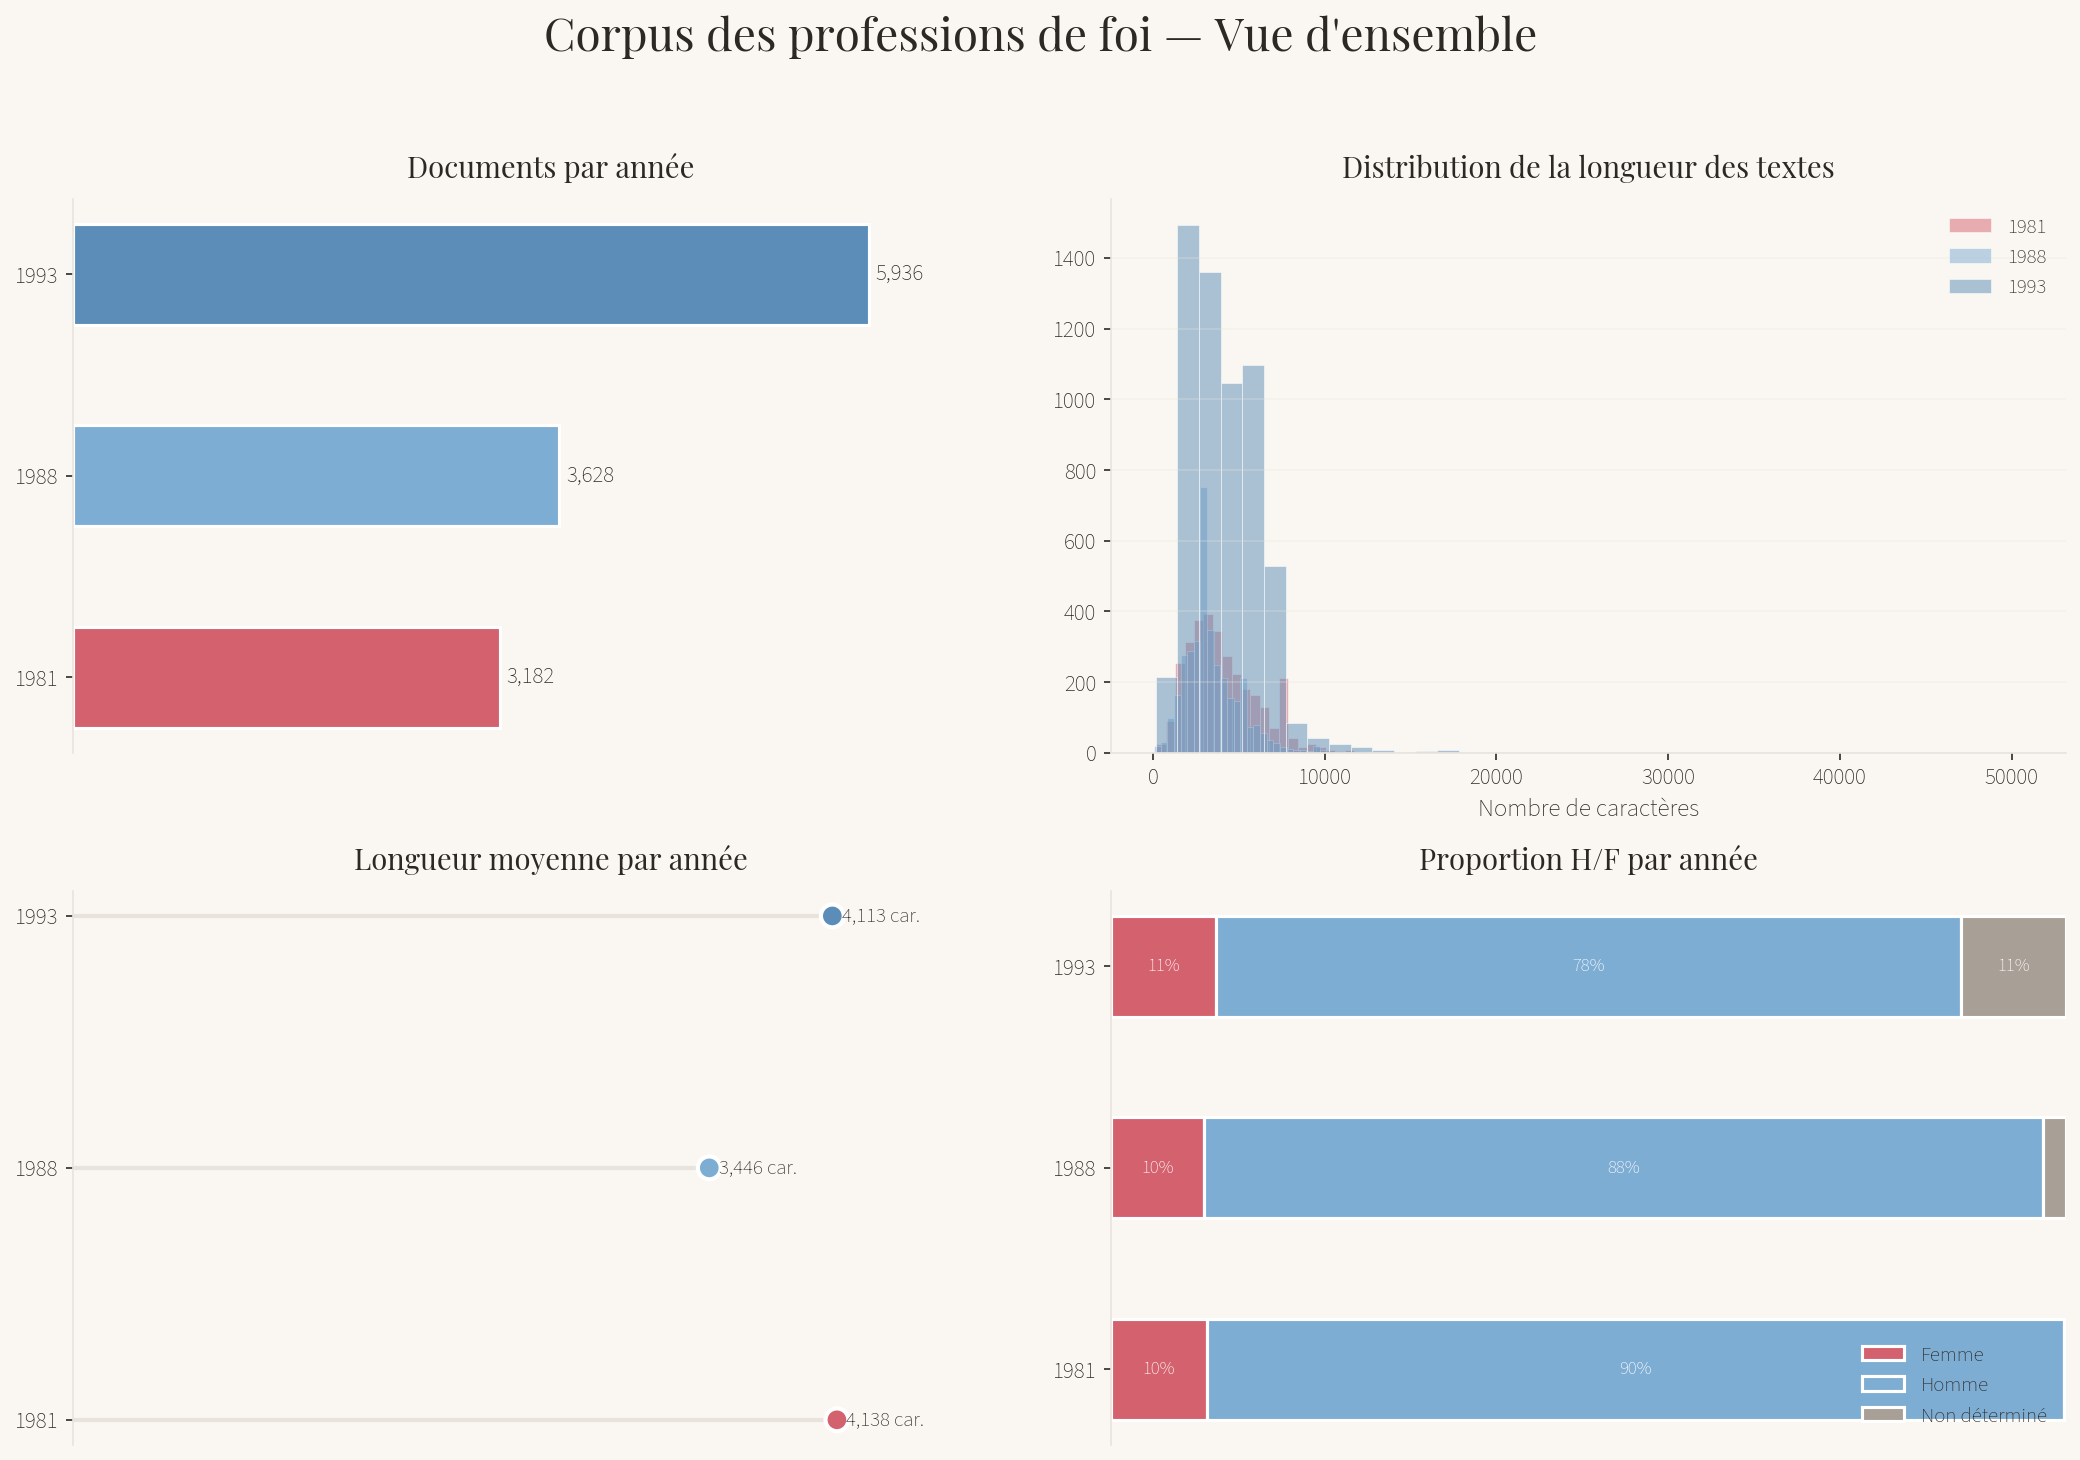

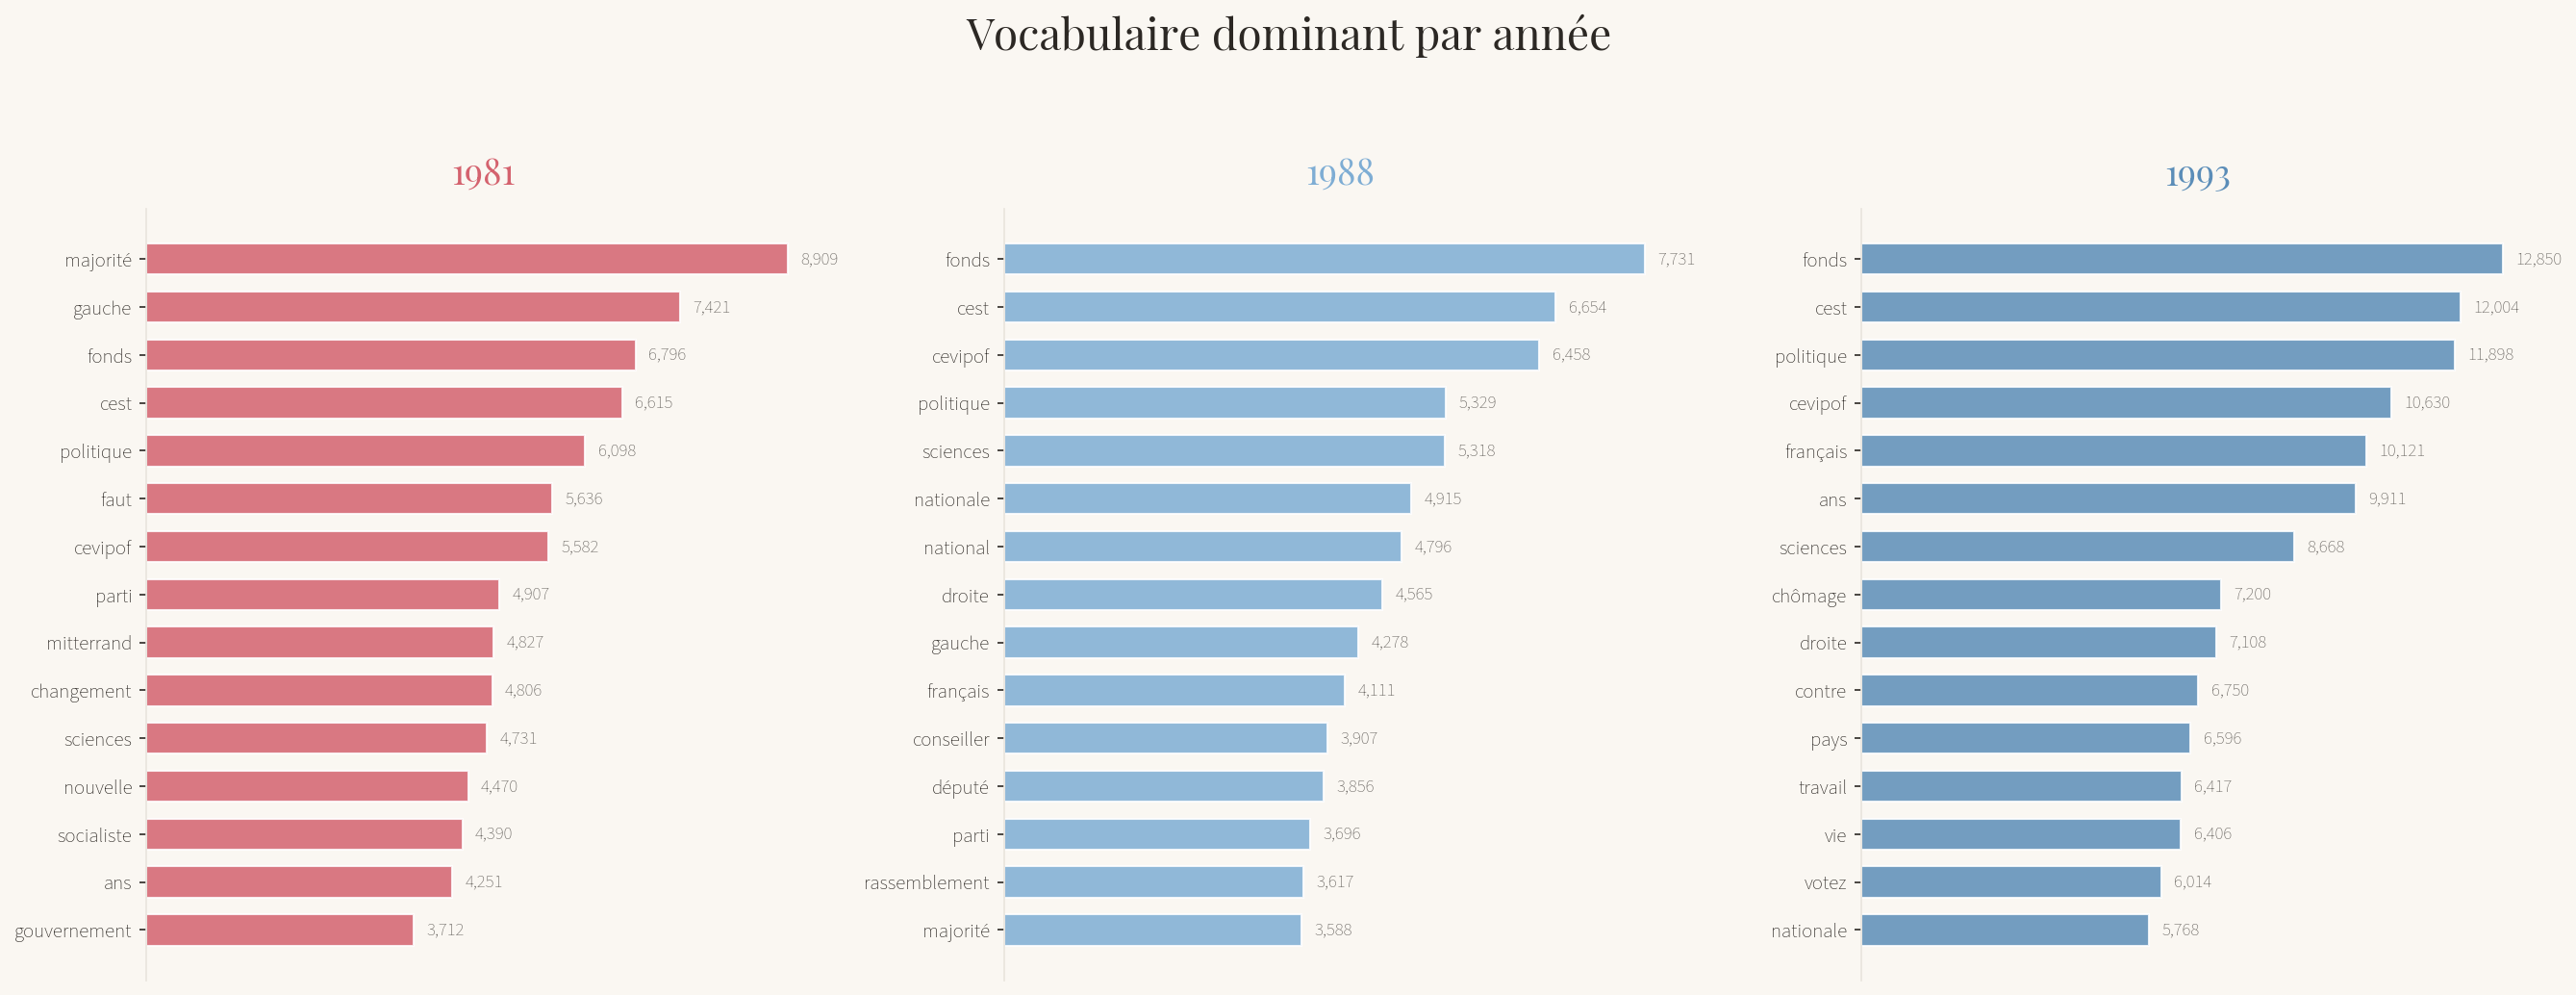

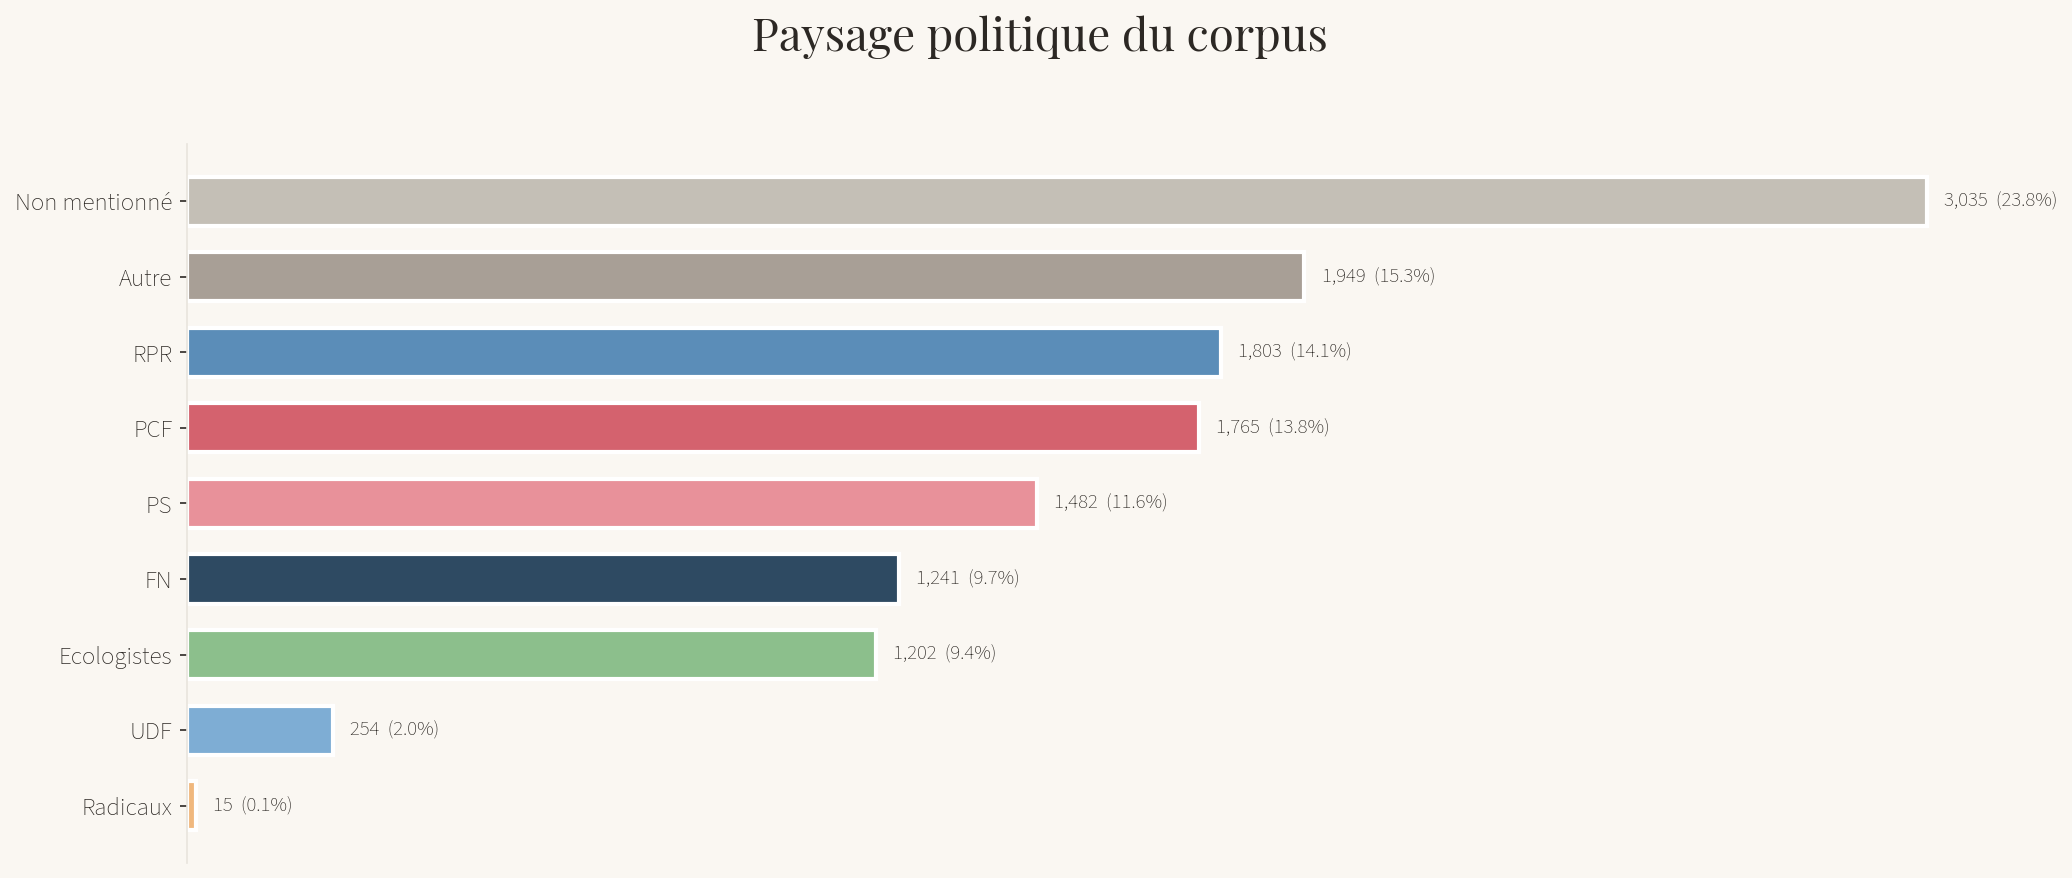

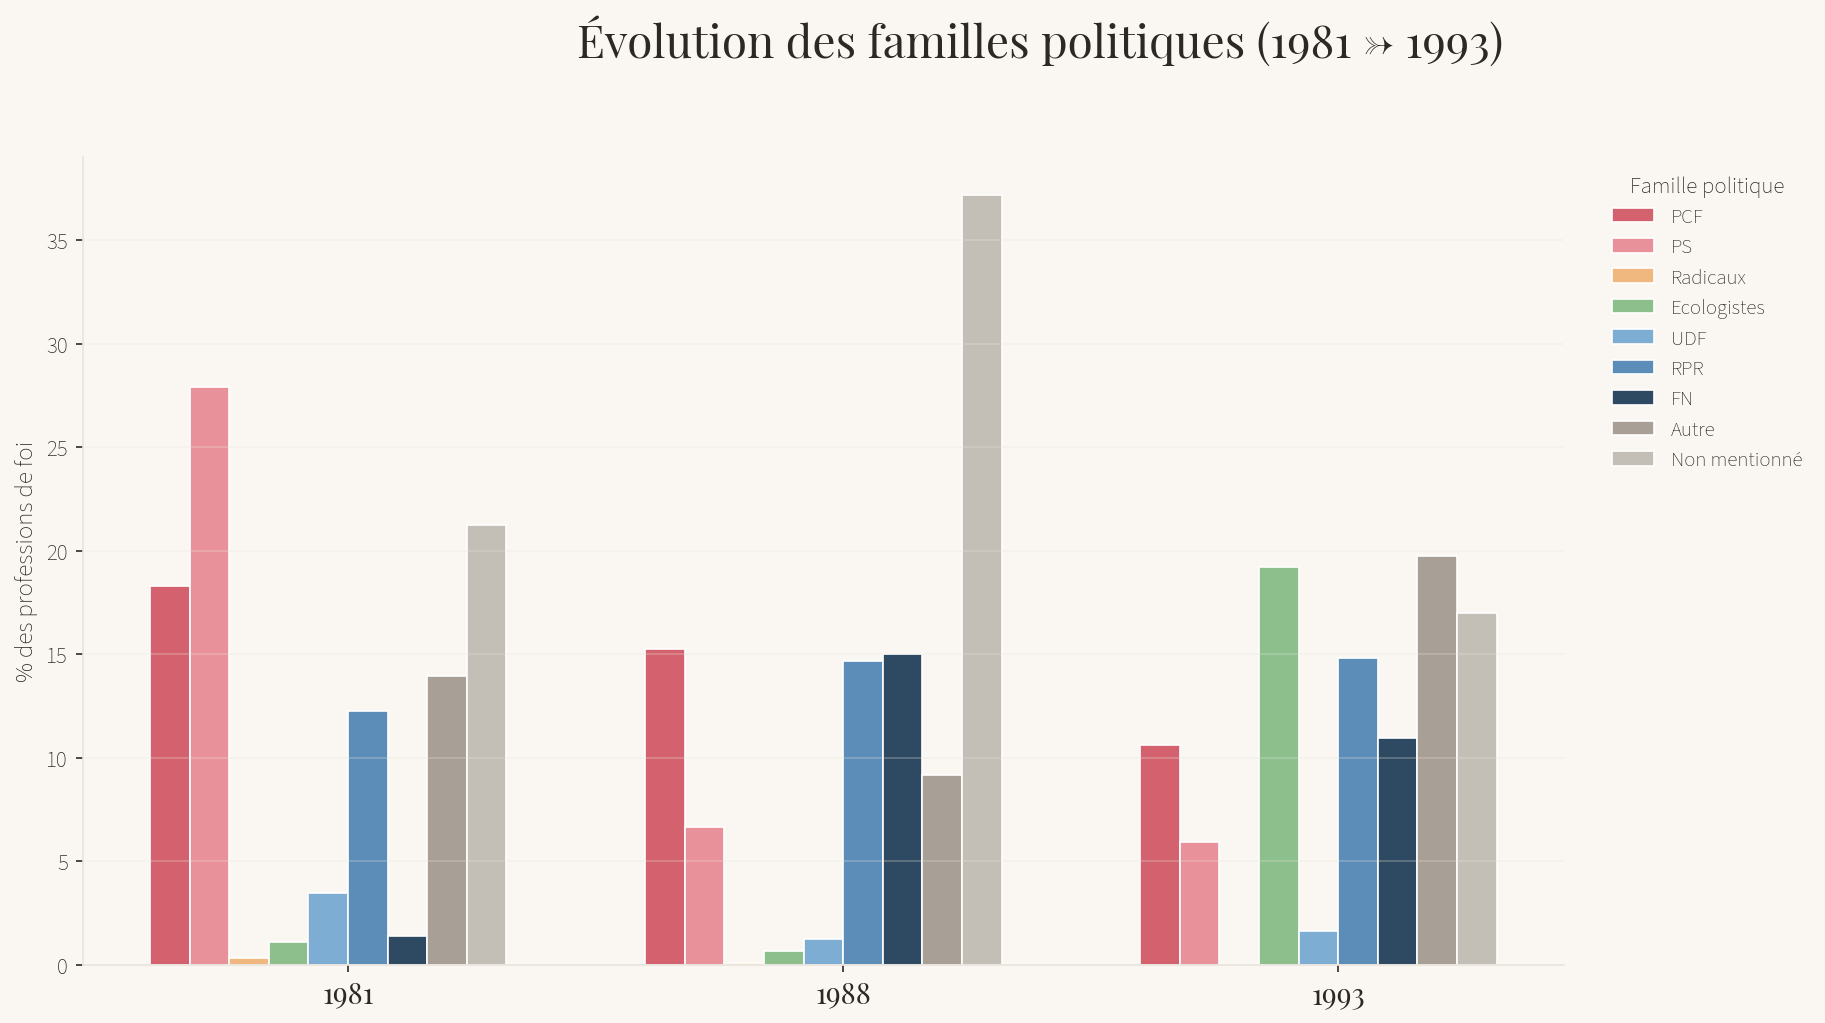

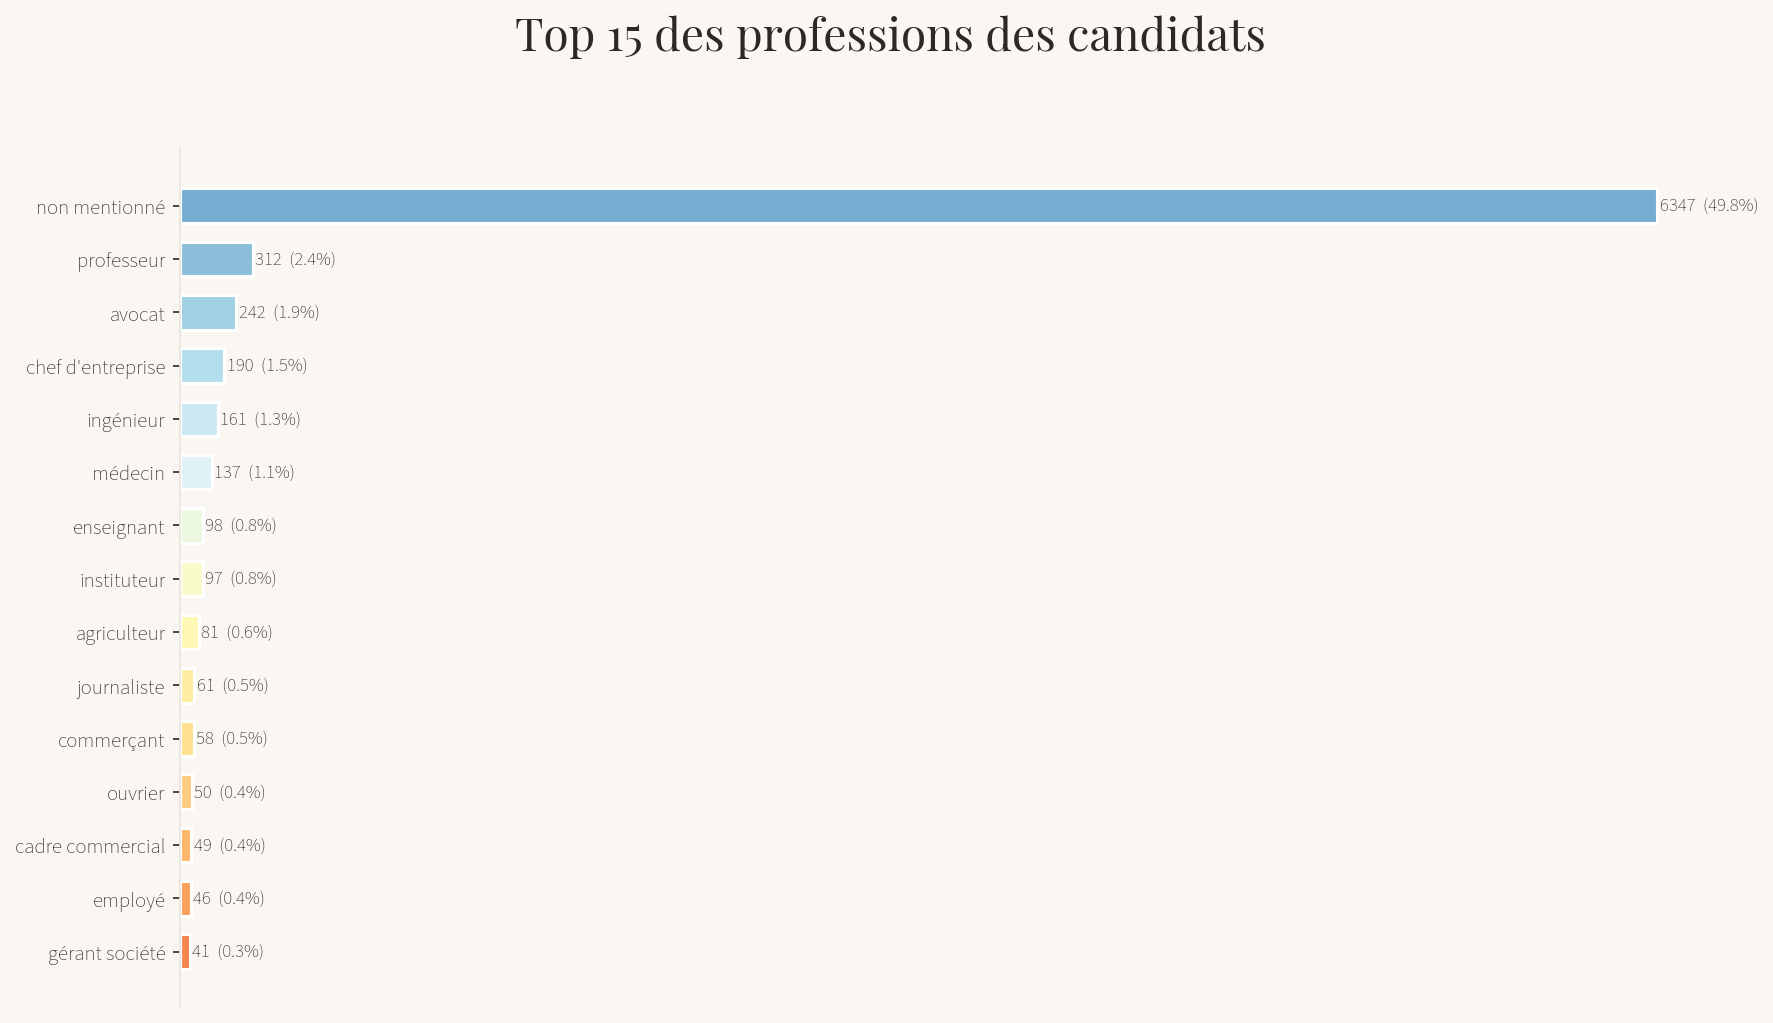


✓ Toutes les figures sauvegardées dans ../data/


In [17]:
# =============================================================================
# 2. Configuration esthétique
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns
import numpy as np

import urllib.request
import os

FONT_DIR = os.path.expanduser("~/.fonts")
os.makedirs(FONT_DIR, exist_ok=True)

fonts_to_download = {
    "Playfair Display": "https://github.com/google/fonts/raw/main/ofl/playfairdisplay/PlayfairDisplay%5Bwght%5D.ttf",
    "Source Sans 3": "https://github.com/google/fonts/raw/main/ofl/sourcesans3/SourceSans3%5Bwght%5D.ttf",
}

for name, url in fonts_to_download.items():
    path = os.path.join(FONT_DIR, f"{name}.ttf")
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
        print(f"Téléchargé : {name}")

font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Playfair Display.ttf"))
font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Source Sans 3.ttf"))

FONT_TITLE = 'Playfair Display'
FONT_BODY = 'Source Sans 3'

PARTY_COLORS = {
    'PCF':            '#D4626E',  # rouge rosé
    'PS':             '#E8919A',  # rose pâle
    'Radicaux':       '#F0B87E',  # abricot
    'Ecologistes':    '#8CBF8C',  # vert sauge
    'UDF':            '#7EADD4',  # bleu ciel
    'RPR':            '#5B8DB8',  # bleu acier
    'FN':             '#2E4A62',  # bleu marine foncé
    'Non mentionné':  '#C4BFB6',  # grège
    'Autre':          '#A89F96',  # taupe
}

# Couleurs années
YEAR_COLORS = {
    '1981': '#D4626E',
    '1988': '#7EADD4',
    '1993': '#5B8DB8',
}

# Fond crème doux
BG_COLOR = '#FAF7F2'
TEXT_COLOR = '#2C2824'
GRID_COLOR = '#E8E4DD'
ACCENT_COLOR = '#D4626E'

# Style global matplotlib
plt.rcParams.update({
    'figure.facecolor': BG_COLOR,
    'axes.facecolor': BG_COLOR,
    'axes.edgecolor': GRID_COLOR,
    'axes.labelcolor': TEXT_COLOR,
    'text.color': TEXT_COLOR,
    'xtick.color': TEXT_COLOR,
    'ytick.color': TEXT_COLOR,
    'grid.color': GRID_COLOR,
    'grid.alpha': 0.5,
    'font.family': FONT_BODY,
    'font.size': 11,
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print("Style configuré ✓")

# =============================================================================
# 3. Figure 1 — Vue d'ensemble du corpus (2×2)
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Corpus des professions de foi — Vue d'ensemble",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

# 3a. Documents par année — barres horizontales élégantes
ax = axes[0, 0]
year_counts = df['year'].value_counts().sort_index()
bars = ax.barh(year_counts.index, year_counts.values, height=0.5,
               color=[YEAR_COLORS.get(y, '#A89F96') for y in year_counts.index],
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, year_counts.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=11, fontweight='bold', color=TEXT_COLOR)
ax.set_title("Documents par année", fontfamily=FONT_TITLE, fontsize=14, pad=10)
ax.set_xlim(0, year_counts.max() * 1.2)
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

# 3b. Distribution longueur — histogramme avec courbe KDE
ax = axes[0, 1]
for year in sorted(df['year'].unique()):
    subset = df[df['year'] == year]['text_length']
    ax.hist(subset, bins=40, alpha=0.5, label=year,
            color=YEAR_COLORS.get(year, '#A89F96'), edgecolor='white', linewidth=0.5)
ax.set_title("Distribution de la longueur des textes", fontfamily=FONT_TITLE, fontsize=14, pad=10)
ax.set_xlabel("Nombre de caractères")
ax.legend(frameon=False, fontsize=10)
ax.grid(axis='y', alpha=0.3)

# 3c. Longueur moyenne par année — lollipop chart
ax = axes[1, 0]
mean_lengths = df.groupby('year')['text_length'].mean().sort_index()
ax.hlines(mean_lengths.index, 0, mean_lengths.values, color=GRID_COLOR, linewidth=2)
ax.scatter(mean_lengths.values, mean_lengths.index, s=120, zorder=3,
           color=[YEAR_COLORS.get(y, '#A89F96') for y in mean_lengths.index],
           edgecolors='white', linewidth=2)
for y, val in zip(mean_lengths.index, mean_lengths.values):
    ax.text(val + 50, y, f'{val:,.0f} car.', va='center', fontsize=10, color=TEXT_COLOR)
ax.set_title("Longueur moyenne par année", fontfamily=FONT_TITLE, fontsize=14, pad=10)
ax.set_xlim(0, mean_lengths.max() * 1.25)
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

# 3d. Répartition H/F par année — barres empilées proportionnelles
ax = axes[1, 1]
ct = pd.crosstab(df['year'], df['titulaire-sexe'], normalize='index') * 100
ct_sorted = ct.sort_index()
colors_sexe = {'homme': '#7EADD4', 'femme': ACCENT_COLOR}
# Vérifier les noms exacts des colonnes
col_names = ct_sorted.columns.tolist()
bottom = np.zeros(len(ct_sorted))
for col in col_names:
    color = colors_sexe.get(col, '#A89F96')
    ax.barh(ct_sorted.index, ct_sorted[col], left=bottom, height=0.5,
            label=col.capitalize(), color=color, edgecolor='white', linewidth=1.5)
    for i, (val, b) in enumerate(zip(ct_sorted[col], bottom)):
        if val > 5:
            ax.text(b + val/2, ct_sorted.index[i], f'{val:.0f}%',
                    ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    bottom += ct_sorted[col].values
ax.set_title("Proportion H/F par année", fontfamily=FONT_TITLE, fontsize=14, pad=10)
ax.set_xlim(0, 100)
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.legend(frameon=False, loc='lower right', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("../data/exploration_base.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

# =============================================================================
# 4. Figure 2 — Top mots par année (graphique éditorial)
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Vocabulaire dominant par année",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.98, color=TEXT_COLOR)

for i, year in enumerate(sorted(df['year'].unique())):
    ax = axes[i]
    top = get_top_words(df[df['year'] == year], 15)
    words, counts = zip(*top)
    max_count = max(counts)

    color = YEAR_COLORS.get(year, '#A89F96')
    bars = ax.barh(range(len(words)), counts, height=0.65,
                   color=color, alpha=0.85, edgecolor='white', linewidth=1)

    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10, fontfamily=FONT_BODY)
    ax.invert_yaxis()
    ax.set_title(year, fontfamily=FONT_TITLE, fontsize=18, fontweight='bold',
                 color=color, pad=12)
    ax.xaxis.set_visible(False)
    ax.spines['bottom'].set_visible(False)

    for bar, val in zip(bars, counts):
        ax.text(val + max_count * 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9, color=TEXT_COLOR, alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/top_mots_par_annee.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

# =============================================================================
# 5. Figure 3 — Paysage politique (treemap-style)
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("Paysage politique du corpus",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

party_counts = df['parti_famille'].value_counts()
parties = party_counts.index.tolist()
counts = party_counts.values

# Barres horizontales triées
colors = [PARTY_COLORS.get(p, '#A89F96') for p in parties]
bars = ax.barh(range(len(parties)), counts, height=0.65,
               color=colors, edgecolor='white', linewidth=2)

ax.set_yticks(range(len(parties)))
ax.set_yticklabels(parties, fontsize=12, fontfamily=FONT_BODY, fontweight='bold')
ax.invert_yaxis()
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

for bar, val, party in zip(bars, counts, parties):
    pct = val / len(df) * 100
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=10, color=TEXT_COLOR)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/paysage_politique.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

# =============================================================================
# 6. Figure 4 — Évolution des familles politiques par année
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Évolution des familles politiques (1981 → 1993)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

# Proportions par année
ct = pd.crosstab(df['year'], df['parti_famille'], normalize='index') * 100
ct = ct.sort_index()

# Garder les partis principaux triés par importance
main_parties = ['PCF', 'PS', 'Radicaux', 'Ecologistes', 'UDF', 'RPR', 'FN', 'Autre', 'Non mentionné']
main_parties = [p for p in main_parties if p in ct.columns]

x = np.arange(len(ct.index))
width = 0.08
n_parties = len(main_parties)

for i, party in enumerate(main_parties):
    offset = (i - n_parties/2) * width
    color = PARTY_COLORS.get(party, '#A89F96')
    bars = ax.bar(x + offset, ct[party], width=width, label=party,
                  color=color, edgecolor='white', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(ct.index, fontsize=14, fontfamily=FONT_TITLE, fontweight='bold')
ax.set_ylabel("% des professions de foi", fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False,
          fontsize=10, title="Famille politique",
          title_fontproperties={'weight': 'bold', 'size': 11})

plt.tight_layout(rect=[0, 0, 0.88, 0.93])
plt.savefig("../data/evolution_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

# =============================================================================
# 7. Figure 5 — Professions des candidats (top 15)
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Top 15 des professions des candidats",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

prof_counts = df['titulaire-profession'].value_counts().head(15)
# Gradient de couleur du accent au neutre
cmap = plt.cm.RdYlBu_r
colors_gradient = [cmap(0.2 + 0.6 * i / len(prof_counts)) for i in range(len(prof_counts))]

bars = ax.barh(range(len(prof_counts)), prof_counts.values, height=0.65,
               color=colors_gradient, edgecolor='white', linewidth=1.5)
ax.set_yticks(range(len(prof_counts)))
ax.set_yticklabels(prof_counts.index, fontsize=10, fontfamily=FONT_BODY)
ax.invert_yaxis()
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

for bar, val in zip(bars, prof_counts.values):
    pct = val / len(df) * 100
    ax.text(val + 10, bar.get_y() + bar.get_height()/2,
            f'{val}  ({pct:.1f}%)', va='center', fontsize=9, color=TEXT_COLOR)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/professions_candidats.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

print("\n✓ Toutes les figures sauvegardées dans ../data/")

In [18]:
# les professions brutes
print(df['titulaire-profession'].value_counts().head(20))
print("\nExemples contenant 'professeur' :")
mask = df['titulaire-profession'].str.contains('professeur', case=False, na=False)
print(f"Nombre : {mask.sum()}")
print(df.loc[mask, 'titulaire-profession'].value_counts().head(10))

titulaire-profession
non mentionné          6347
professeur              312
avocat                  242
chef d'entreprise       190
ingénieur               161
médecin                 137
enseignant               98
instituteur              97
agriculteur              81
journaliste              61
commerçant               58
ouvrier                  50
cadre commercial         49
employé                  46
gérant société           41
technicien               41
médecin généraliste      38
directeur école          37
cadre                    35
docteur                  35
Name: count, dtype: int64

Exemples contenant 'professeur' :
Nombre : 687
titulaire-profession
professeur                                   312
professeur collège                            30
professeur Université                         20
professeur lycée                              16
professeur agrégé                             12
professeur lettres                            10
professeur mathématiques      

In [19]:
# Compter les professions par mot-clé (comme dans les stats officielles)
profession_keywords = [
    'professeur', 'directeur', 'ingénieur', 'cadre', 'chef',
    'entreprise', 'médecin', 'agent', 'avocat', 'agriculteur',
    'ouvrier', 'commercial'
]

prof_counts = {}
for keyword in profession_keywords:
    mask = df['titulaire-profession'].str.contains(keyword, case=False, na=False)
    prof_counts[keyword] = mask.sum()

prof_series = pd.Series(prof_counts).sort_values(ascending=False)
print("Comptage par mot-clé :")
print(prof_series)

Comptage par mot-clé :
professeur     687
ingénieur      357
directeur      336
entreprise     334
chef           309
médecin        306
avocat         293
cadre          281
agent          179
commercial     173
ouvrier        165
agriculteur     97
dtype: int64


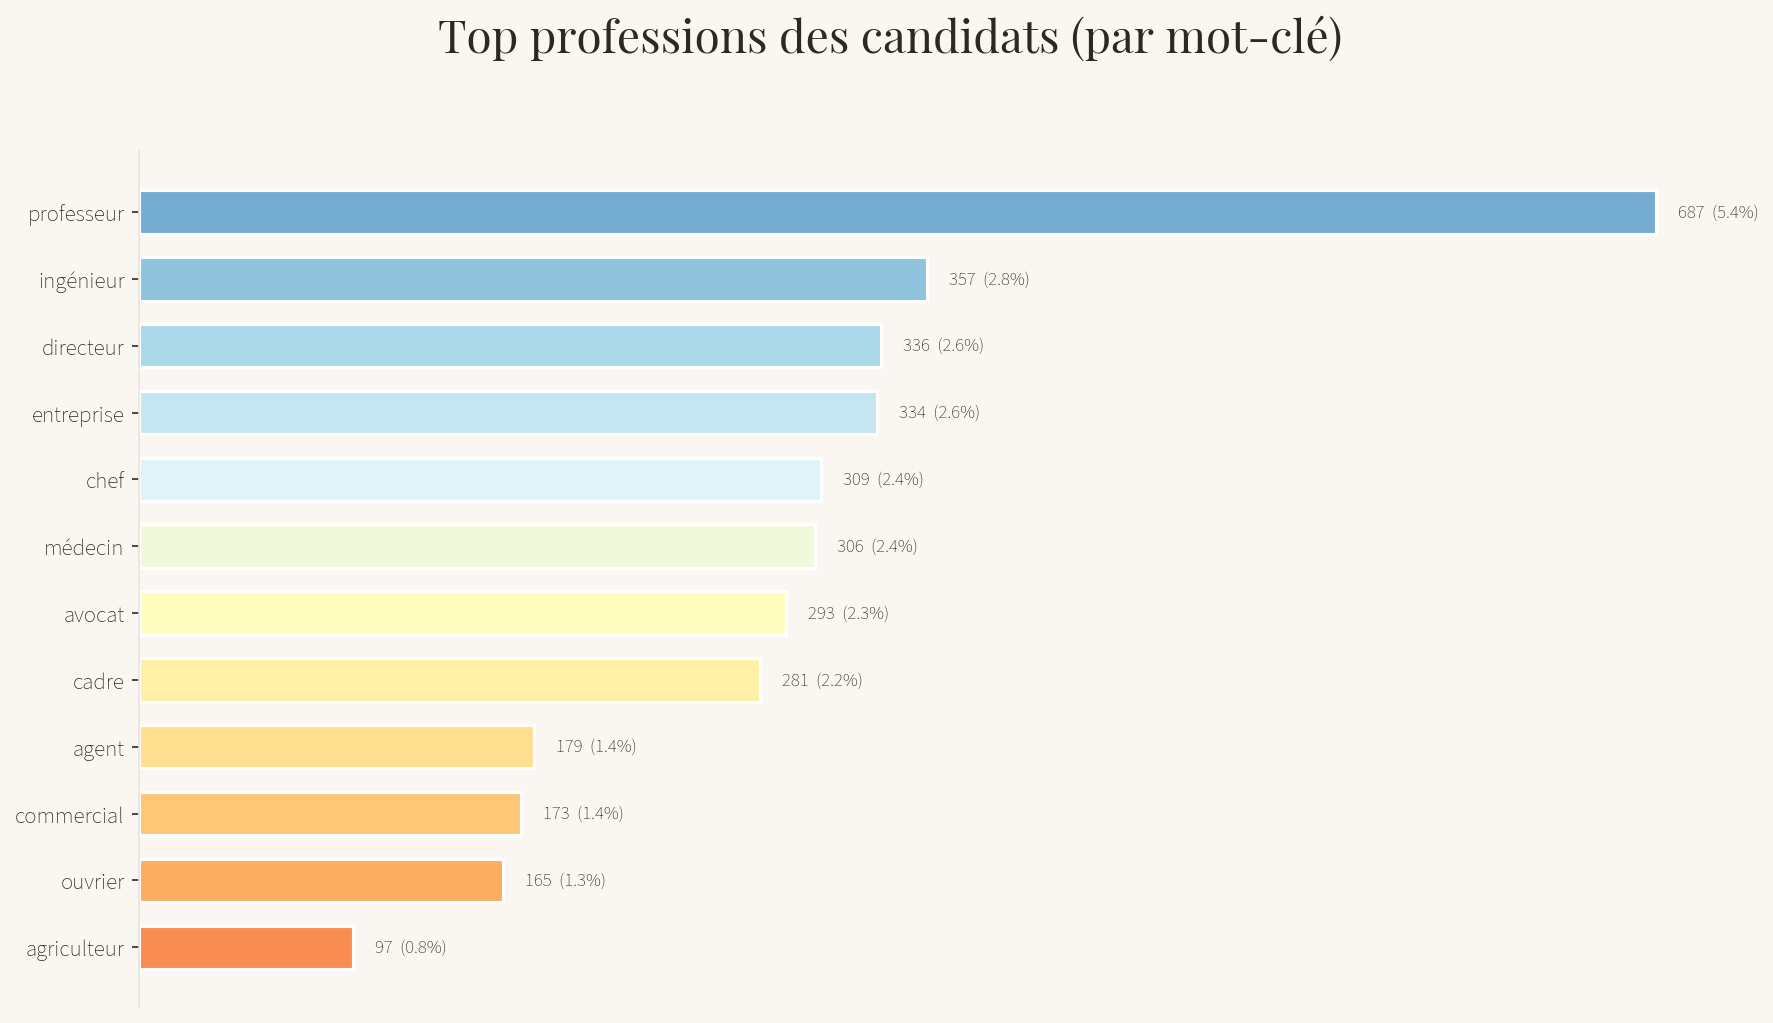

In [20]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Top professions des candidats (par mot-clé)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold',
             y=0.97, color=TEXT_COLOR)

cmap = plt.cm.RdYlBu_r
colors_gradient = [cmap(0.2 + 0.6 * i / len(prof_series)) for i in range(len(prof_series))]

bars = ax.barh(range(len(prof_series)), prof_series.values, height=0.65,
               color=colors_gradient, edgecolor='white', linewidth=1.5)
ax.set_yticks(range(len(prof_series)))
ax.set_yticklabels(prof_series.index, fontsize=11, fontfamily=FONT_BODY)
ax.invert_yaxis()
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)

for bar, val in zip(bars, prof_series.values):
    pct = val / len(df) * 100
    ax.text(val + 10, bar.get_y() + bar.get_height()/2,
            f'{val}  ({pct:.1f}%)', va='center', fontsize=9, color=TEXT_COLOR)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/professions_candidats.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

In [21]:
# Lister TOUTES les professions uniques
professions = df['titulaire-profession'].value_counts()
print(f"Nombre de professions uniques : {len(professions)}")
print(f"\nListe complète :\n")
for i, (prof, count) in enumerate(professions.items()):
    print(f"{i+1:4d}. ({count:4d})  {prof}")

Nombre de professions uniques : 2032

Liste complète :

   1. (6347)  non mentionné
   2. ( 312)  professeur
   3. ( 242)  avocat
   4. ( 190)  chef d'entreprise
   5. ( 161)  ingénieur
   6. ( 137)  médecin
   7. (  98)  enseignant
   8. (  97)  instituteur
   9. (  81)  agriculteur
  10. (  61)  journaliste
  11. (  58)  commerçant
  12. (  50)  ouvrier
  13. (  49)  cadre commercial
  14. (  46)  employé
  15. (  41)  gérant société
  16. (  41)  technicien
  17. (  38)  médecin généraliste
  18. (  37)  directeur école
  19. (  35)  cadre
  20. (  35)  docteur
  21. (  33)  docteur en médecine
  22. (  33)  ouvrier métallurgiste
  23. (  32)  chirurgien-dentiste
  24. (  30)  docteur-vétérinaire
  25. (  30)  professeur collège
  26. (  29)  maître de conférences
  27. (  28)  enseignante
  28. (  28)  fonctionnaire
  29. (  27)  employée
  30. (  27)  institutrice
  31. (  26)  vétérinaire
  32. (  26)  expert-comptable
  33. (  26)  directeur commercial
  34. (  25)  infirmière
 

In [22]:
pip install transformers torch

Note: you may need to restart the kernel to use updated packages.


In [23]:
pip install sentencepiece protobuf

Note: you may need to restart the kernel to use updated packages.


In [24]:
# =============================================================================
# Classification des professions avec un modèle Transformer (zero-shot)
# =============================================================================

from transformers import pipeline
from tqdm import tqdm
print("Chargement du modèle... ")
# Charger le modèle zero-shot
classifier = pipeline(
    "zero-shot-classification",
    model="joeddav/xlm-roberta-large-xnli",
    device=-1  
)

# Définir les catégories PCS simplifiées
PCS_CATEGORIES = [
    "Agriculteur, exploitant agricole",
    "Artisan, commerçant, chef d'entreprise",
    "Profession médicale ou paramédicale",
    "Profession juridique",
    "Enseignant, chercheur, universitaire",
    "Cadre supérieur, ingénieur",
    "Cadre moyen, technicien",
    "Employé, fonctionnaire",
    "Ouvrier",
    "Journaliste, artiste, communication",
    "Militaire, policier, sécurité",
    "Profession commerciale, vente",
    "Étudiant, retraité, sans emploi",
    "Permanent politique ou syndical",
    "Profession religieuse",
]

# Classifier les professions unique (pas les 12000 lignes)
#    Beaucoup de candidats ont la même profession, on classe chaque
#    profession unique une seule fois puis on fait la jointure

unique_professions = df['titulaire-profession'].dropna().unique()
print(f"Professions uniques à classifier : {len(unique_professions)}")

# Filtrer les "non mentionné"
to_classify = [p for p in unique_professions 
               if isinstance(p, str) and p.lower().strip() not in ['non mentionné', '']]
print(f"Professions à envoyer au modèle : {len(to_classify)}")

# Classification par batch
results = {}
batch_size = 16

for i in tqdm(range(0, len(to_classify), batch_size), desc="Classification"):
    batch = to_classify[i:i+batch_size]
    
    for profession in batch:
        try:
            result = classifier(
                profession,
                candidate_labels=PCS_CATEGORIES,
                hypothesis_template="Cette personne travaille comme {}."
            )
            results[profession] = result['labels'][0]  # catégorie la plus probable
        except Exception as e:
            results[profession] = 'Autre'

# Ajouter "Non renseigné" pour les non mentionnés
for p in unique_professions:
    if p not in results:
        results[p] = 'Non renseigné'

print(f"\nProfessions classifiées : {len(results)}")

# Appliquer au DataFrame
df['profession_pcs'] = df['titulaire-profession'].map(results)
df['profession_pcs'] = df['profession_pcs'].fillna('Non renseigné')



print("\n=== Répartition par catégorie PCS ===\n")
pcs_counts = df['profession_pcs'].value_counts()
for cat, count in pcs_counts.items():
    pct = count / len(df) * 100
    print(f"  {cat:50s} {count:5d}  ({pct:5.1f}%)")

print(f"\nTotal : {len(df)}")

# exemples
print("\n=== Exemples de classification ===\n")
sample_profs = df[['titulaire-profession', 'profession_pcs']].drop_duplicates()
print(sample_profs.sample(20).to_string(index=False))

Chargement du modèle... 


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 4454.02it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: joeddav/xlm-roberta-large-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Professions uniques à classifier : 2032
Professions à envoyer au modèle : 2031


Classification: 100%|██████████| 127/127 [1:52:48<00:00, 53.30s/it]


Professions classifiées : 2032

=== Répartition par catégorie PCS ===

  Non renseigné                                       6596  ( 51.7%)
  Enseignant, chercheur, universitaire                1456  ( 11.4%)
  Profession juridique                                1157  (  9.1%)
  Employé, fonctionnaire                              1030  (  8.1%)
  Ouvrier                                              628  (  4.9%)
  Cadre supérieur, ingénieur                           557  (  4.4%)
  Profession commerciale, vente                        396  (  3.1%)
  Cadre moyen, technicien                              357  (  2.8%)
  Agriculteur, exploitant agricole                     249  (  2.0%)
  Journaliste, artiste, communication                   95  (  0.7%)
  Profession religieuse                                 73  (  0.6%)
  Artisan, commerçant, chef d'entreprise                51  (  0.4%)
  Profession médicale ou paramédicale                   43  (  0.3%)
  Militaire, policier, sécurité